In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, History
import kagglehub
from tensorflow.python.keras.saving.saved_model_experimental import sequential

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
# Download the dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Path to dataset files:", path)

# Define paths (assuming standard structure: afhq/train and afhq/val with subfolders cat, dog, wild)
data_dir = os.path.join(path, 'afhq')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')  # This is the test set in this task

num_classes = 3  # cat, dog, wild

# This is new way to load data(you can even set batch size by it if you want!):
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(512, 512),
    class_mode='categorical',
    # batch_size= 128
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(512, 512),
    class_mode='categorical',
    shuffle=False,
    # batch_size=128
)

# Note: The 'val' folder is used as the test set here. If you need a validation set, split the data from the train set.

Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces
Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


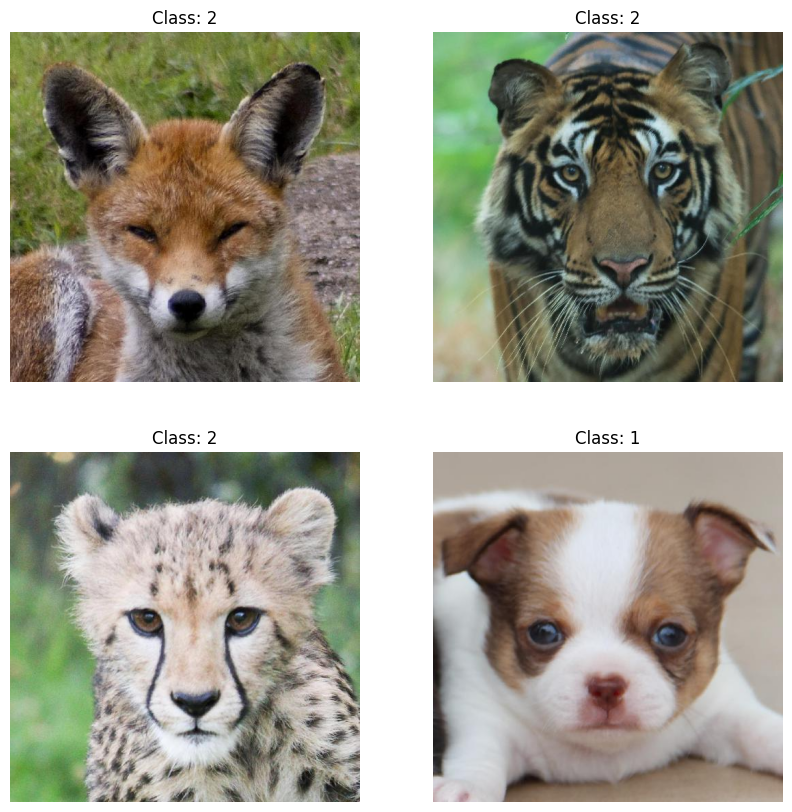

In [3]:
# Optional: Visualize a batch of images to confirm loading
import matplotlib.pyplot as plt

images, labels = next(train_generator)  # Get one batch
plt.figure(figsize=(10, 10))
for i in range(4):  # Show first 4 images
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(f'Class: {labels[i].argmax()}')
    plt.axis('off')
plt.show()

In [4]:
# Function to plot training history (accuracy and loss curves)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Function to evaluate on test set
def evaluate_model(model):
    test_loss, test_acc = model.evaluate(test_generator)
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 106s 228ms/step - accuracy: 0.3427 - loss: 240.2215
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 105s 229ms/step - accuracy: 0.3579 - loss: 1.0978
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 106s 232ms/step - accuracy: 0.3492 - loss: 1.0986
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 105s 229ms/step - accuracy: 0.3506 - loss: 1.0984
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 104s 227ms/step - accuracy: 0.3473 - loss: 1.0985


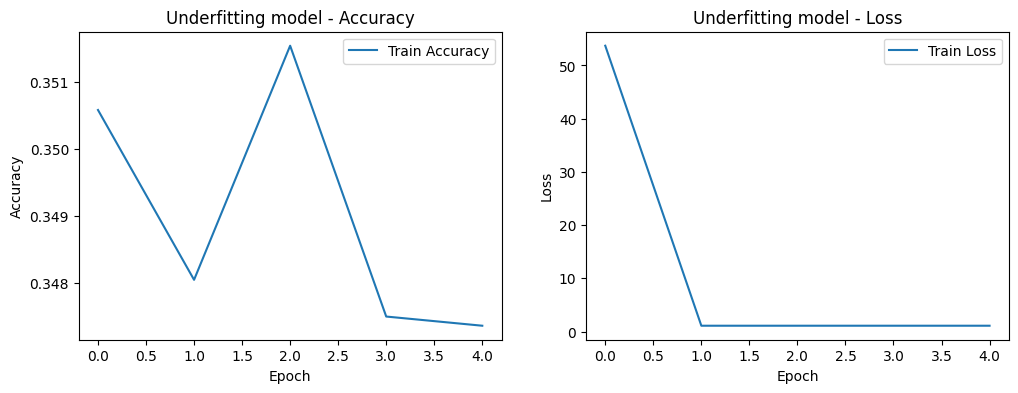

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.0728 - loss: 1.0967
Test Accuracy: 0.3333


0.3333333432674408

In [13]:
# Cell 1: Create an underfitting model
# Goal: Design a simple ANN (e.g., few layers, small neurons) that underfits the data.
# Train it on the train set (no validation split needed here).
# Observe high bias: similar poor performance on train and test.
# After training, use plot_history(history, 'Underfitting') and evaluate_model(model)

# Your code here:
# model = Sequential([...])  # Simple CNN or MLP
# model.compile(...)
# history = model.fit(train_generator, epochs=...)
# plot_history(...)
# evaluate_model(...)

model = Sequential([Flatten(),
                    Dense(32, activation=tf.nn.relu),
                    Dense(3,activation=tf.nn.softmax)])
model.compile(loss=tf.keras.losses.categorical_crossentropy,optimizer=Adam(0.01),metrics=['accuracy'])
history = model.fit(train_generator,epochs=5)
plot_history(history, 'Underfitting model')
evaluate_model(model)

Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Epoch 1/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.4658 - loss: 1.0114
Epoch 2/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 139ms/step - accuracy: 0.7192 - loss: 0.6646
Epoch 3/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 31s 133ms/step - accuracy: 0.7775 - loss: 0.5606
Epoch 4/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 141ms/step - accuracy: 0.7933 - loss: 0.5238
Epoch 5/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 138ms/step - accuracy: 0.8095 - loss: 0.4852
Epoch 6/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 33s 143ms/step - accuracy: 0.8183 - loss: 0.4610
Epoch 7/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 33s 143ms/step - accuracy: 0.8269 - loss: 0.4450
Epoch 8/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step - accuracy: 0.8420 - loss: 0.4210
Epoch 9/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 34s 148ms/step - accuracy: 0.8589 - loss: 0.3691
Epoch 10/40
229/229 ━━━━━━━━━━━━━━━━━━━━ 33s 143ms/step - accuracy: 0.8590 - loss: 0.3832
Epoch 11/40
229/229 ━━━━

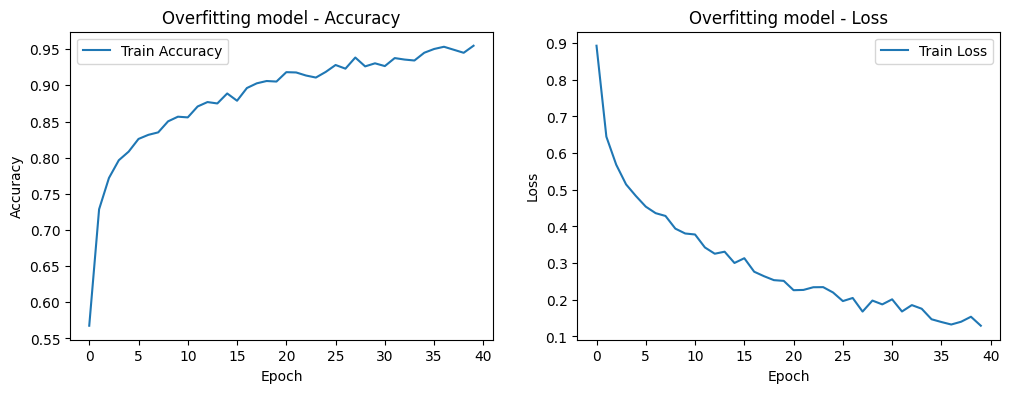

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.8525 - loss: 0.5361
Test Accuracy: 0.8533


0.8533333539962769

In [ ]:
# Cell 2: Create an overfitting model
# Goal: Design a complex ANN (e.g., many layers, large neurons) that overfits.
# Train for many epochs without regularization.
# Observe low bias but high variance: good on train, poor on test.
# After training, use plot_history(history, 'Overfitting') and evaluate_model(model)

# Your code here:
# model = Sequential([...])  # Complex model
# model.compile(...)
# history = model.fit(train_generator, epochs=...)
# plot_history(...)
# evaluate_model(...)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    class_mode='categorical',
    batch_size=64
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    class_mode='categorical',
    shuffle=False,
    batch_size=64
)
model = Sequential([
    Flatten(),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'],optimizer=Adam())
history = model.fit(train_generator,epochs=30,batch_size=64)

plot_history(history,'Overfitting model')
evaluate_model(model)

Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Epoch 1/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - accuracy: 0.4136 - loss: 20.0099
Epoch 2/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.6592 - loss: 2.2462
Epoch 3/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.7133 - loss: 1.3707
Epoch 4/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.7578 - loss: 1.0909
Epoch 5/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - accuracy: 0.7794 - loss: 0.9574
Epoch 6/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.7923 - loss: 0.8835
Epoch 7/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.8000 - loss: 0.8234
Epoch 8/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.7937 - loss: 0.8079
Epoch 9/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.8152 - loss: 0.7420
Epoch 10/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.8296 - loss: 0.6963
Epoch 11/30
229/229 ━━━

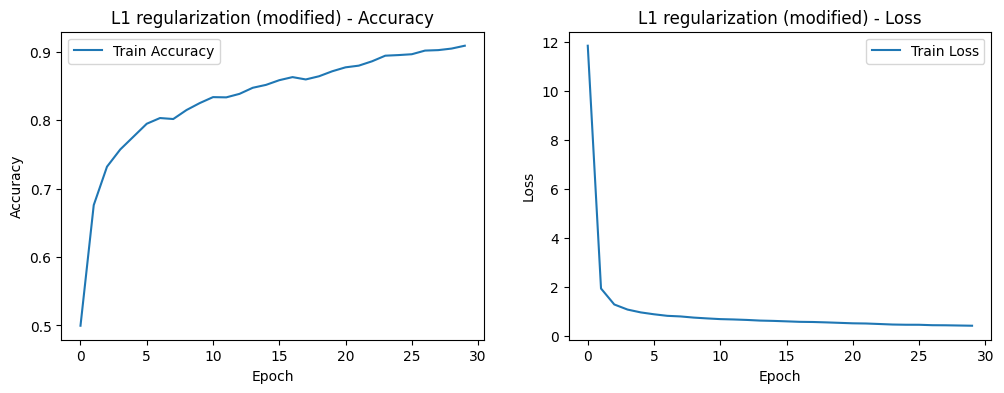

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.8472 - loss: 0.5588
Test Accuracy: 0.8513


0.8513333201408386

In [6]:
# Cell 3: Add L1 Regularization
# Goal: Modify a model (perhaps the overfitting one) by adding L1 regularizers to layers.
# e.g., Dense(..., kernel_regularizer=l1(0.01))
# Train and observe how it reduces overfitting.
# Optional: Split validation from train if needed (e.g., validation_split=0.2 in fit)
# After training, plot and evaluate.

# Your code here:
model = Sequential([
    Flatten(),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(32, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(3, activation='softmax', kernel_regularizer=l1(0.01))
])

model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])
history = model.fit(train_generator, epochs=20)
plot_history(history, 'L1 regularization (modified)')
evaluate_model(model)

Epoch 1/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - accuracy: 0.4855 - loss: 3.1828
Epoch 2/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.7141 - loss: 1.1547
Epoch 3/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 119ms/step - accuracy: 0.7654 - loss: 0.8551
Epoch 4/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.7831 - loss: 0.7365
Epoch 5/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.8100 - loss: 0.6288
Epoch 6/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.8174 - loss: 0.5878
Epoch 7/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.8359 - loss: 0.5287
Epoch 8/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.8461 - loss: 0.4974
Epoch 9/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.8486 - loss: 0.4819
Epoch 10/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.8582 - loss: 0.4549
Epoch 11/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 119ms/step - accuracy: 0.8573 - loss: 0.4469
Epoch 12/30
229/229

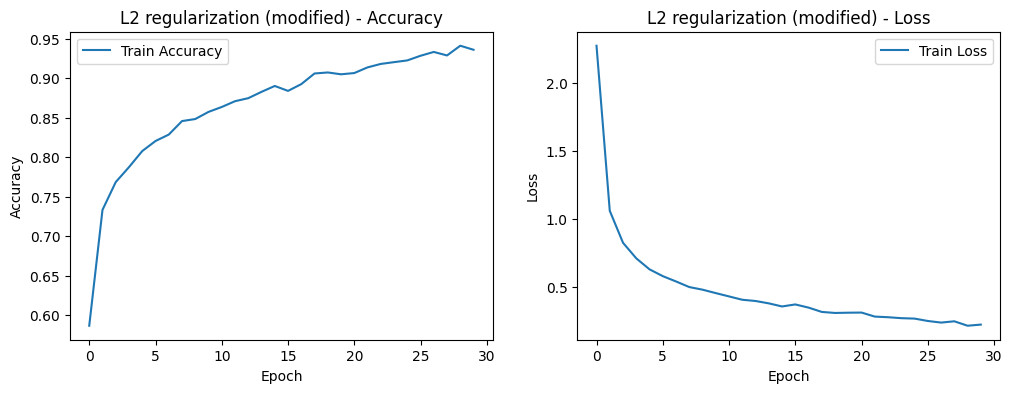

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.8375 - loss: 0.5440
Test Accuracy: 0.8547


0.8546666502952576

In [7]:
# Cell 4: Add L2 Regularization
# Goal: Similar to above, but use L2 (weight decay).
# e.g., Dense(..., kernel_regularizer=l2(0.01))
# Compare with L1.
# Optional validation split.
# Plot and evaluate.

# Your code here:

model = Sequential([
    Flatten(),
    Dense(256, activation='relu'),
    Dense(256, activation='relu',kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.01))
])

model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])
history = model.fit(train_generator, epochs=30)
plot_history(history, 'L2 regularization')
evaluate_model(model)

Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - accuracy: 0.3437 - loss: 1.1323
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.5641 - loss: 0.9284
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.6574 - loss: 0.7904
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.6951 - loss: 0.7117
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.7113 - loss: 0.6822
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.7154 - loss: 0.6714
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 109ms/step - accuracy: 0.7380 - loss: 0.6303
Epoch 8/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.7344 - loss: 0.6217
Epoch 9/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.7488 - loss: 0.6033
Epoch 10/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.7511 - loss: 0.6048
Epoch 11/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.7351 - loss: 0.6393
Epoch 12/20
229/229

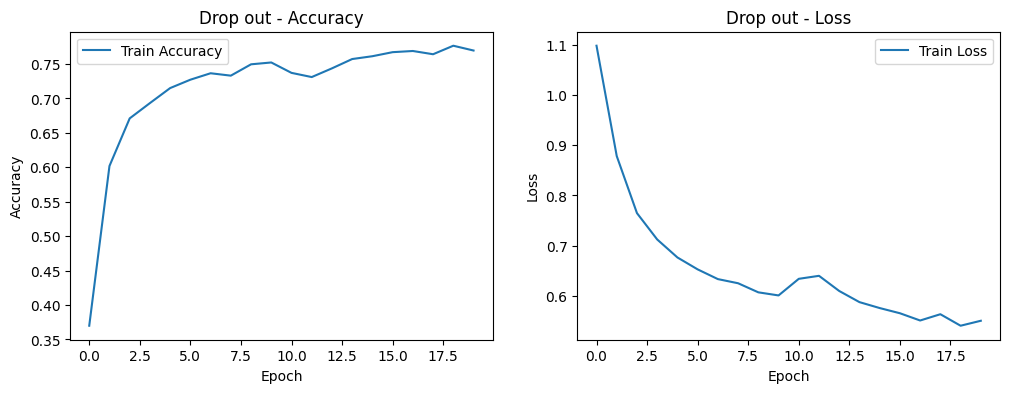

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.7161 - loss: 0.6494
Test Accuracy: 0.7760


0.7760000228881836

In [17]:
# Cell 5: Add Dropout
# Goal: Add Dropout layers to prevent overfitting.
# e.g., Dropout(0.5) after Dense layers.
# Train, plot, evaluate.
# Optional validation.

# Your code here:

model = Sequential([
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),

    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(128, activation='relu'),

    Dense(3, activation='softmax')
])



model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])
history = model.fit(train_generator, epochs=20)
plot_history(history, 'Drop out')
evaluate_model(model)

## this cell can probably improve a lot with more epochs but I didn't have enough time to give it a try :(

Found 11706 images belonging to 3 classes.
Found 2924 images belonging to 3 classes.
Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 38s 183ms/step - accuracy: 0.3476 - loss: 1.6017 - val_accuracy: 0.5068 - val_loss: 1.0184
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.5413 - loss: 0.9681 - val_accuracy: 0.5469 - val_loss: 0.9972
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.6128 - loss: 0.8663 - val_accuracy: 0.6084 - val_loss: 0.8508
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 32s 173ms/step - accuracy: 0.6443 - loss: 0.8153 - val_accuracy: 0.7083 - val_loss: 0.7203
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 37s 205ms/step - accuracy: 0.6872 - loss: 0.7464 - val_accuracy: 0.7110 - val_loss: 0.6941
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 33s 181ms/step - accuracy: 0.7111 - loss: 0.7060 - val_accuracy: 0.7216 - val_loss: 0.6778
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.7291 - loss: 0.6799 - val_accuracy: 0.7367 - val_loss: 0.666

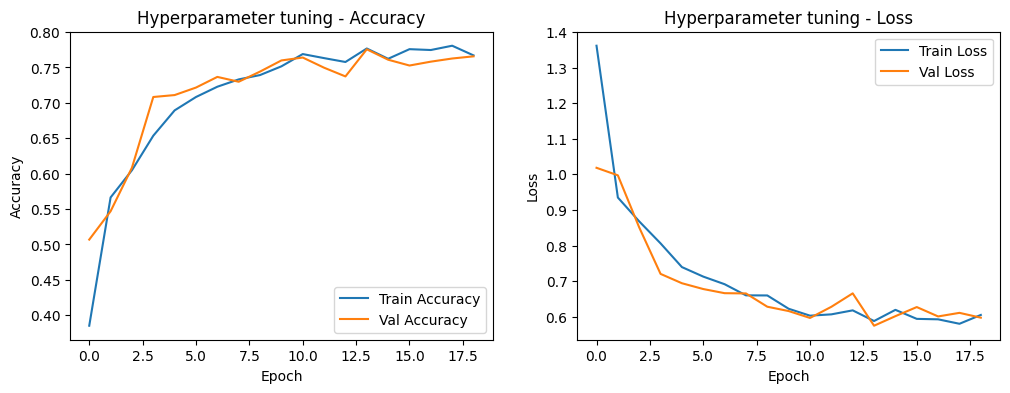

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.7483 - loss: 0.6049
Test Accuracy: 0.7867


0.7866666913032532

In [9]:
# Cell 6: Hyperparameter Tuning
# Goal: Experiment with hyperparameters like learning rate, batch size, epochs, optimizer.
# Use callbacks like EarlyStopping if needed.
# e.g., optimizer=Adam(learning_rate=0.001)
# Try different values and see impact.
# Must use validation split here to tune.
# Plot and evaluate the best one.

# Your code here:

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),

    Dense(256, activation='relu'),

    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),

    Dense(64, activation='relu',kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(128, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=Adam(learning_rate=0.002), metrics=['accuracy'])

train_datagen_split = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_split = train_datagen_split.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    subset='training',
)

val_gen_split = train_datagen_split.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
)


early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen_split,
    epochs=20,
    validation_data=val_gen_split,
    callbacks=[early_stopping]
)

plot_history(history, 'Hyperparameter tuning')
evaluate_model(model)

## no overfit (thank god!), but also not a really high accuracy :(

Epoch 1/3
183/183 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.5770 - loss: 16.0008 - val_accuracy: 0.8906 - val_loss: 0.3727
Epoch 2/3
183/183 ━━━━━━━━━━━━━━━━━━━━ 35s 191ms/step - accuracy: 0.9246 - loss: 0.2795 - val_accuracy: 0.8950 - val_loss: 0.3237
Epoch 3/3
183/183 ━━━━━━━━━━━━━━━━━━━━ 34s 186ms/step - accuracy: 0.9532 - loss: 0.1737 - val_accuracy: 0.9384 - val_loss: 0.2369


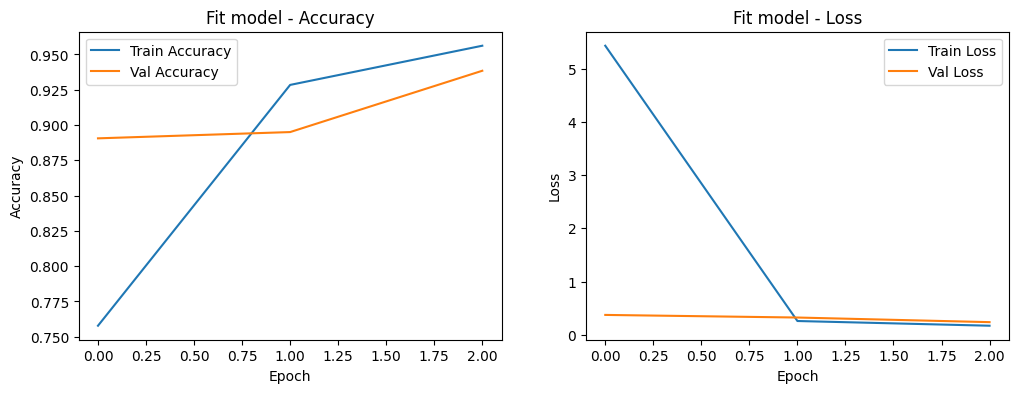

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.9489 - loss: 0.2145
Test Accuracy: 0.9460


0.9459999799728394

In [16]:
# Cell 7: Combined Approach
# Goal: Combine techniques (L1/L2, Dropout, Tuning) for balanced learning.
# Aim for good generalization: similar performance on train/val/test.
# Validation optional but recommended.
# Plot and evaluate.

# Your code here:
model = Sequential([
    Conv2D(32, (3,3), input_shape = (64,64,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(units = 7317, activation='relu'),
    Dropout(0.2),
    Dense(units = 7317, activation='relu',kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(units = 3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss=tf.keras.losses.categorical_crossentropy, metrics = ['accuracy'])

train_datagen_split = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# train_gen_split = train_datagen_split.flow_from_directory(
#     train_dir,
#     target_size=(64, 64),
#     batch_size=64,
#     class_mode='categorical',
#     subset='training',
# )

# val_gen_split = train_datagen_split.flow_from_directory(
#     train_dir,
#     target_size=(64, 64),
#     batch_size=64,
#     class_mode='categorical',
#     subset='validation',
# )
# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=(64, 64),
#     class_mode='categorical',
#     shuffle=False,
#     batch_size=64
# )

history = model.fit(train_gen_split, epochs=3, validation_data=val_gen_split)
plot_history(history, 'Fit model')
evaluate_model(model)